In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

Датасет Boston Housing содержит информацию о жилье в районе Бостона, собранную Службой переписи населения США. Он включает 14 признаков, из которых 13 являются входными переменными, а один — целевой (MEDV). Ниже приведено подробное описание каждого признака на основе стандартной документации датасета.

1. **CRIM**: Уровень преступности на душу населения по городам. Этот признак отражает криминальную обстановку в районе и измеряется в относительных единицах.

2. **ZN**: Доля жилой земли, зонированной под участки площадью более 25 000 квадратных футов. Он указывает на наличие крупных жилых зон и выражается в процентах.

3. **INDUS**: Доля акров, занятых не-розничным бизнесом, по городам. Этот показатель характеризует промышленную загруженность района и также выражается в процентах.

4. **CHAS**: Фиктивная переменная, обозначающая близость к реке Чарльз (1, если участок граничит с рекой; 0 в противном случае). Это бинарный признак, влияющий на привлекательность жилья.

5. **NOX**: Концентрация оксидов азота (в частях на 10 миллионов). Он измеряет уровень загрязнения воздуха и связан с экологическими факторами.

6. **RM**: Среднее количество комнат на жилище. Этот признак отражает размер и комфортность домов, измеряемый в количестве комнат.

7. **AGE**: Доля единиц жилья, занимаемых владельцами и построенных до 1940 года. Он указывает на возраст жилого фонда и выражается в процентах.

8. **DIS**: Взвешенные расстояния до пяти центров занятости в Бостоне. Этот показатель оценивает доступность рабочих мест и измеряется в милях.

9. **RAD**: Индекс доступности радиальных шоссе. Он представляет собой категориальный показатель (от 1 до 24), отражающий транспортную инфраструктуру.

10. **TAX**: Ставка налога на имущество полной стоимости на 10 000 долларов. Этот признак характеризует налоговую нагрузку и измеряется в долларах на 10 000 долларов стоимости.

11. **PTRATIO**: Соотношение учеников к учителям по городам. Он отражает качество образования в районе и выражается как отношение.

12. **Black**: Формула 1000(Bk - 0.63)^2, где Bk — доля афроамериканского населения по городам. Этот признак учитывает демографический состав и предназначен для корректировки на социальные факторы.

13. **LSTAT**: Процент населения с низким социально-экономическим статусом. Он измеряется в процентах и связан с уровнем благосостояния жителей.

14. **MEDV**: Медианная стоимость домов, занимаемых владельцами, в тысячах долларов. Это целевая переменная, которую предсказывают модели на основе остальных признаков.

Данные описания основаны на официальной документации датасета.


### Описание данных (ориг)
The medv variable is the target variable.
This data frame contains the following columns:
1. crim per capita crime rate by town.
2. zn proportion of residential land zoned for lots over 25,000 sq.ft.
3. indus proportion of non-retail business acres per town.
4. chas Charles River dummy variable (= 1 if tract bounds river; 0 otherwise).
5. nox nitrogen oxides concentration (parts per 10 million).
6. rm average number of rooms per dwelling.
7. age proportion of owner-occupied units built prior to 1940.
8.  dis weighted mean of distances to five Boston employment centres.
9.  rad index of accessibility to radial highways.
10. tax full-value property-tax rate per $10,000.
11. ptratio pupil-teacher ratio by town.
12. black 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town.
13. lstat lower status of the population (percent).
14. medv median value of owner-occupied homes in $1000s.

In [2]:
data = pd.read_csv("boston_data.csv")
data_test = pd.read_csv("boston_test_data.csv")
data_categorical_features = ['chas', 'rad']
pd.options.mode.use_inf_as_na = True

/var/folders/1f/qzsxtjvd1hgcnxb8nykmnbz00000gn/T/ipykernel_44138/1232329999.py:4: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.options.mode.use_inf_as_na = True


In [3]:
data.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.15876,0.0,10.81,0.0,0.413,5.961,17.5,5.2873,4.0,305.0,19.2,376.94,9.88,21.7
1,0.10328,25.0,5.13,0.0,0.453,5.927,47.2,6.9320,8.0,284.0,19.7,396.90,9.22,19.6
2,0.34940,0.0,9.90,0.0,0.544,5.972,76.7,3.1025,4.0,304.0,18.4,396.24,9.97,20.3
3,2.73397,0.0,19.58,0.0,0.871,5.597,94.9,1.5257,5.0,403.0,14.7,351.85,21.45,15.4
4,0.04337,21.0,5.64,0.0,0.439,6.115,63.0,6.8147,4.0,243.0,16.8,393.97,9.43,20.5


In [4]:
data_test.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat
0,0.07886,80.0,4.95,0.0,0.411,7.148,27.7,5.1167,4.0,245.0,19.2,396.90,3.56
1,0.08873,21.0,5.64,0.0,0.439,5.963,45.7,6.8147,4.0,243.0,16.8,395.56,13.45
2,1.38799,0.0,8.14,0.0,0.538,5.950,82.0,3.9900,4.0,307.0,21.0,232.60,27.71
3,0.30347,0.0,7.38,0.0,0.493,6.312,28.9,5.4159,5.0,287.0,19.6,396.90,6.15
4,0.22927,0.0,6.91,0.0,0.448,6.030,85.5,5.6894,3.0,233.0,17.9,392.74,18.80


In [5]:
print(data.describe())
print(data.var())


             crim          zn       indus        chas         nox         rm  \
count  404.000000  404.000000  404.000000  404.000000  404.000000  404.00000   
mean     3.730912   10.509901   11.189901    0.069307    0.556710    6.30145   
std      8.943922   22.053733    6.814909    0.254290    0.117321    0.67583   
min      0.006320    0.000000    0.460000    0.000000    0.392000    3.56100   
25%      0.082382    0.000000    5.190000    0.000000    0.453000    5.90275   
50%      0.253715    0.000000    9.795000    0.000000    0.538000    6.23050   
75%      4.053158   12.500000   18.100000    0.000000    0.631000    6.62925   
max     88.976200   95.000000   27.740000    1.000000    0.871000    8.78000   

              age         dis         rad         tax     ptratio       black  \
count  404.000000  404.000000  404.000000  404.000000  404.000000  404.000000   
mean    68.601733    3.799666    9.836634  411.688119   18.444554  355.068243   
std     28.066143    2.109916    8.8

In [6]:
data.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
black      0
lstat      0
medv       0
dtype: int64

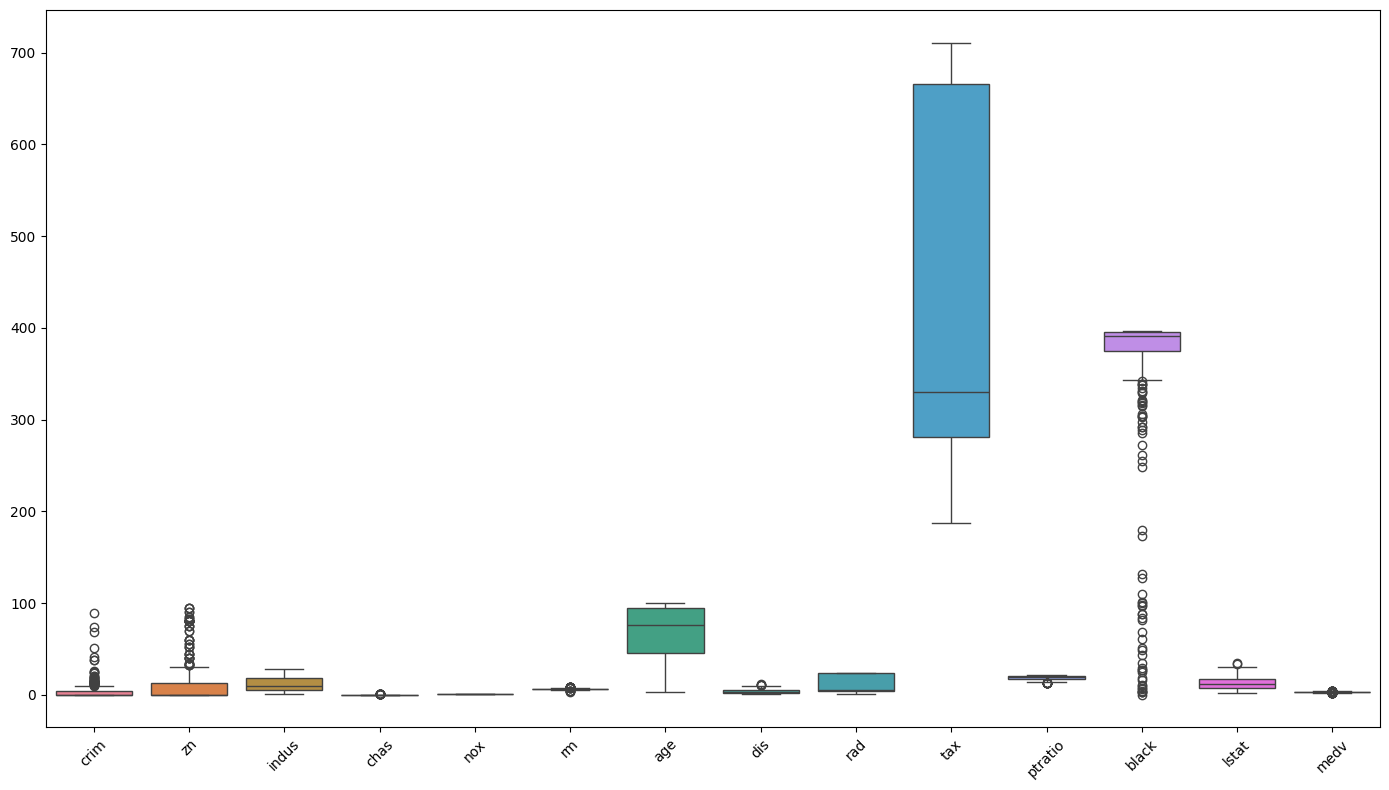

In [7]:
data['medv'] = np.log1p(data['medv'])

plt.rcParams['figure.figsize'] = (14, 8)
plt.figure()
sns.boxplot(data,)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


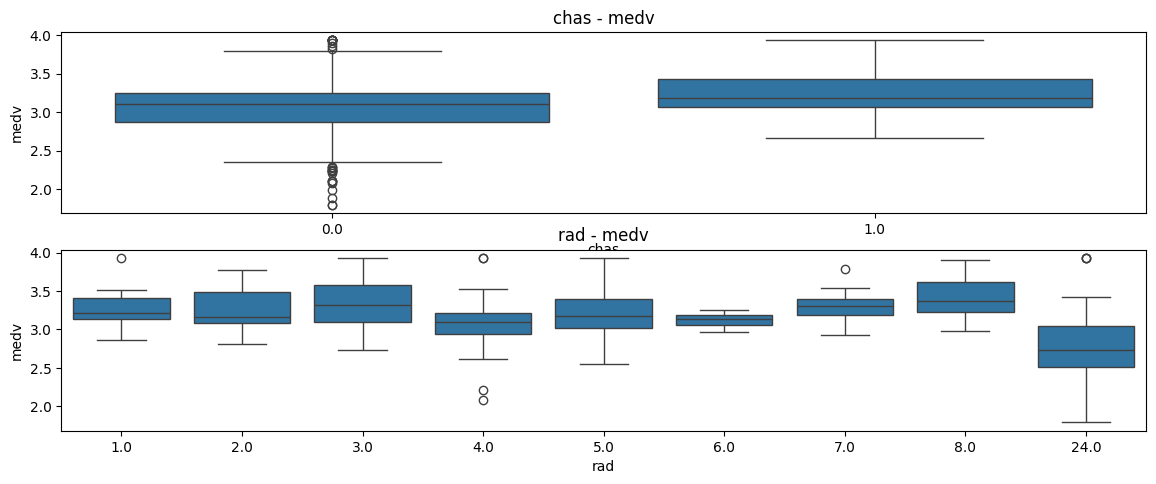

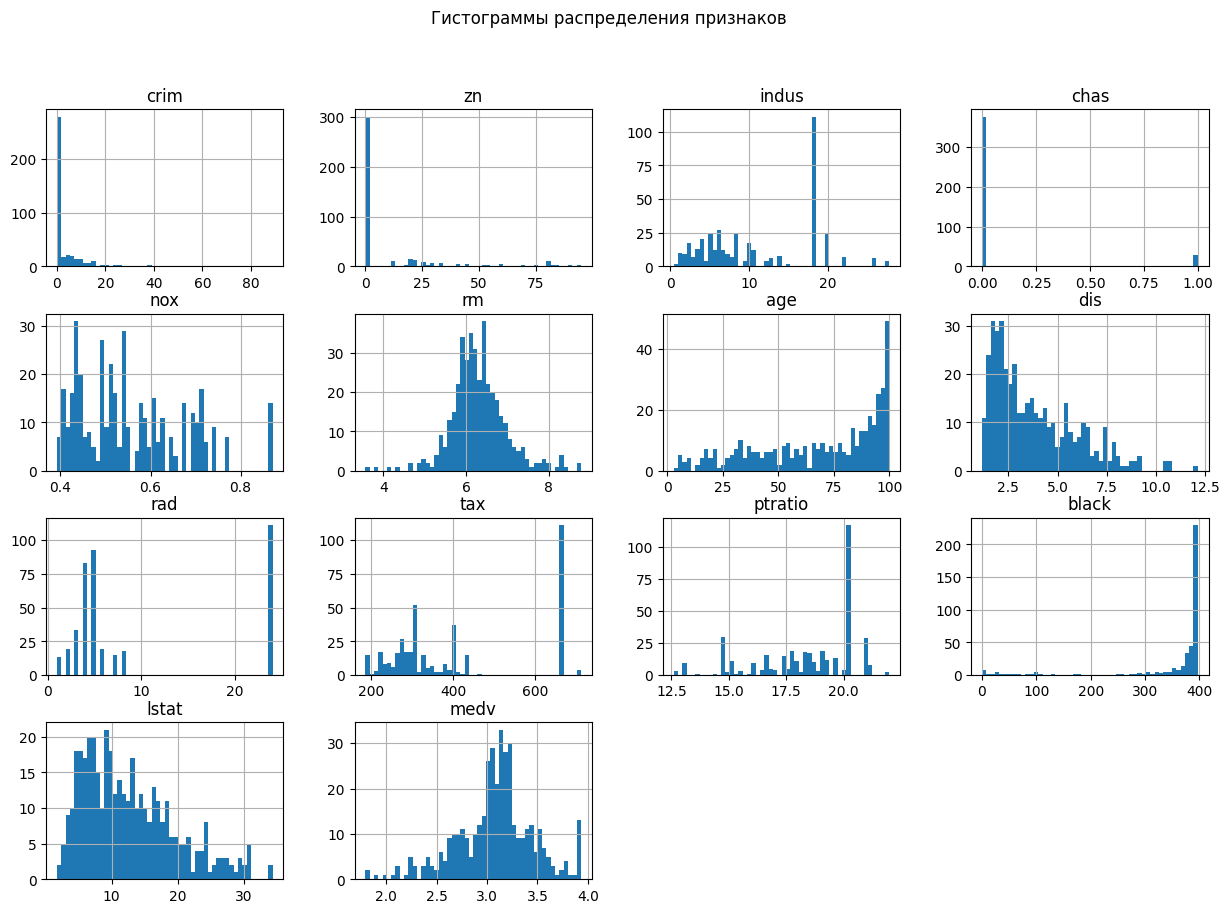

In [8]:
plt.subplot(3, 1, 1)
sns.boxplot(data=data, x='chas', y='medv')
plt.title('chas - medv')
plt.subplot(3, 1, 2)
sns.boxplot(data=data, x='rad', y='medv')
plt.title('rad - medv')
plt.show()


data.hist(figsize=(15, 10), bins=50)
plt.suptitle("Гистограммы распределения признаков")
plt.show()

In [9]:
def remove_outliers_target(df, target_column_name):
    
    column = target_column_name
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    filtered_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    
    return filtered_df

In [10]:
print(f"Original data shape: {data.shape}")

data = remove_outliers_target(data, 'medv')

print(f"Data shape after outlier removal: {data.shape}")

Original data shape: (404, 14)
Data shape after outlier removal: (371, 14)


In [11]:
data.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.15876,0.0,10.81,0.0,0.413,5.961,17.5,5.2873,4.0,305.0,19.2,376.94,9.88,3.122365
1,0.10328,25.0,5.13,0.0,0.453,5.927,47.2,6.9320,8.0,284.0,19.7,396.90,9.22,3.025291
2,0.34940,0.0,9.90,0.0,0.544,5.972,76.7,3.1025,4.0,304.0,18.4,396.24,9.97,3.058707
3,2.73397,0.0,19.58,0.0,0.871,5.597,94.9,1.5257,5.0,403.0,14.7,351.85,21.45,2.797281
4,0.04337,21.0,5.64,0.0,0.439,6.115,63.0,6.8147,4.0,243.0,16.8,393.97,9.43,3.068053


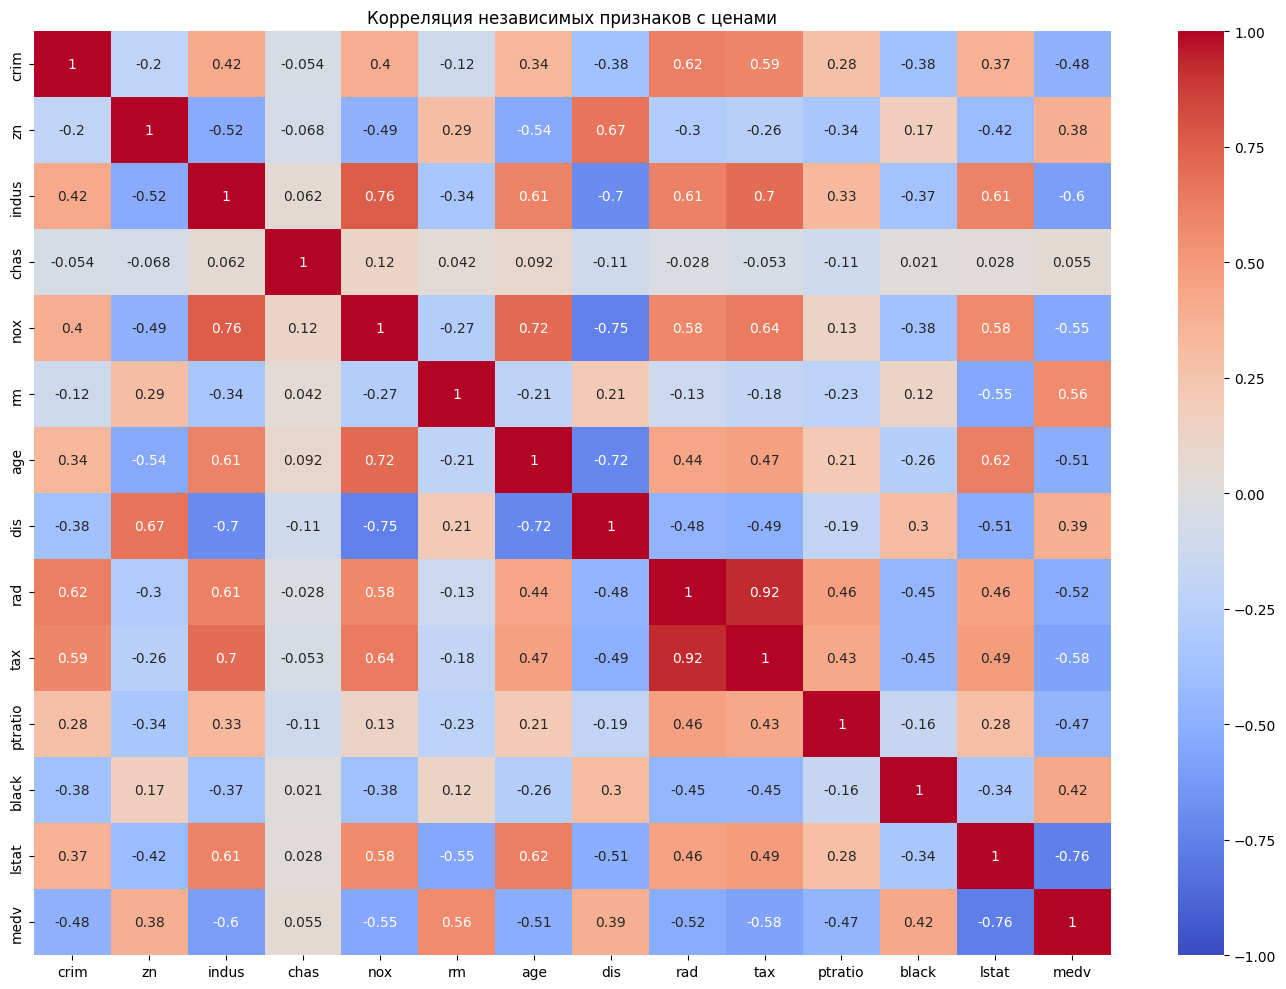

In [12]:
correlation_matrix = data.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Корреляция независимых признаков с ценами")
plt.tight_layout()
plt.show()

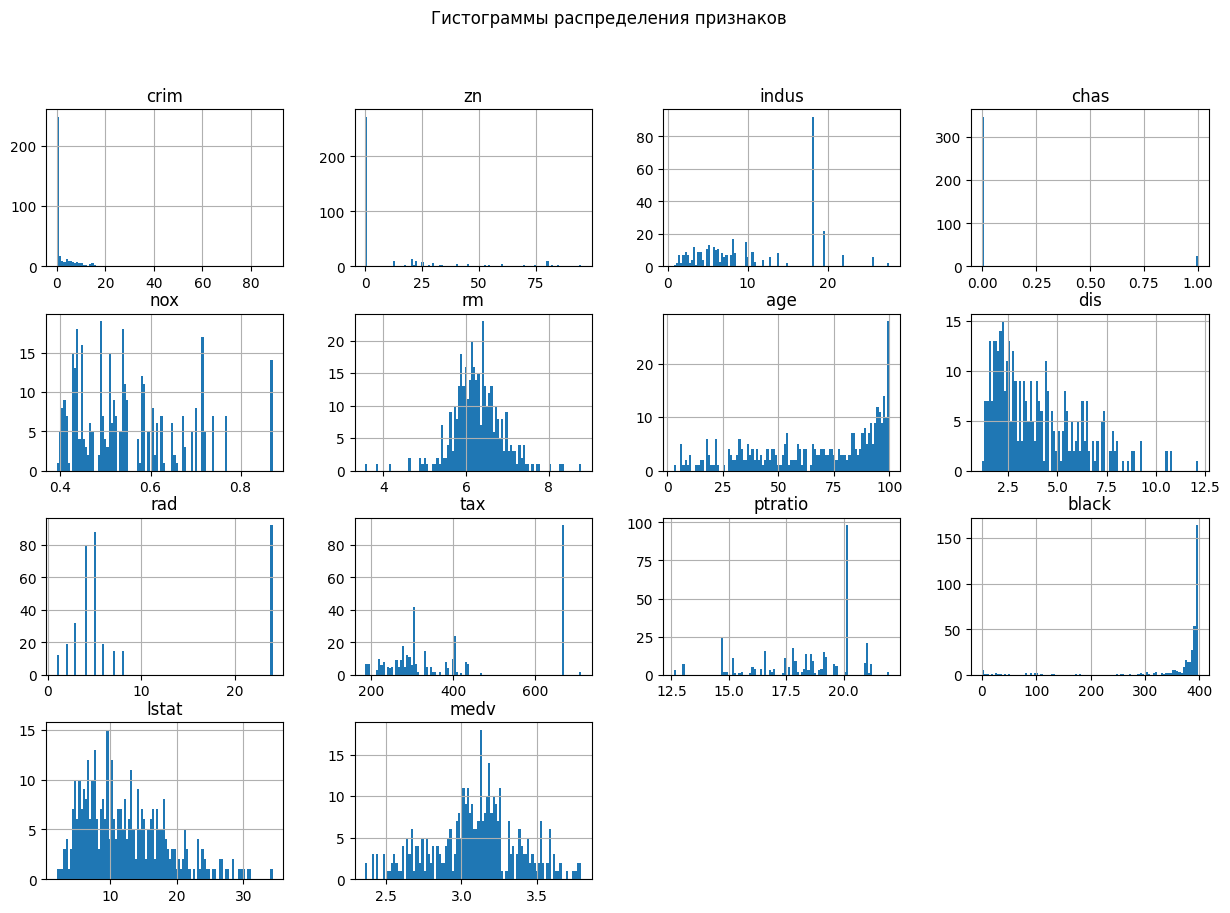

In [13]:
# Построение гистограмм для всех признаков
data.hist(figsize=(15, 10), bins=100)
plt.suptitle("Гистограммы распределения признаков")
plt.show()

In [14]:
data_optimized = data.copy()

y = data_optimized['medv']                      

data_optimized['crim']  = np.log1p(data_optimized['crim'])
data_optimized['dis']   = np.log1p(data_optimized['dis'])
data_optimized['lstat'] = np.log1p(data_optimized['lstat'])

data_optimized['age']   = np.log1p(data_optimized['age'])           
data_optimized['zn_big']    = (data_optimized['zn'] > 0).astype(int)

data_optimized.drop(['zn'], axis=1, inplace=True)
data_categorical_features.append('zn_big')
X = data_optimized.drop('medv', axis=1)
data_optimized.head()

,crim,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv,zn_big
0,0.147350,10.81,0.0,0.413,5.961,2.917771,1.838532,4.0,305.0,19.2,376.94,2.386926,3.122365,0
1,0.098288,5.13,0.0,0.453,5.927,3.875359,2.070905,8.0,284.0,19.7,396.90,2.324347,3.025291,1
2,0.299660,9.90,0.0,0.544,5.972,4.352855,1.411597,4.0,304.0,18.4,396.24,2.395164,3.058707,0
3,1.317472,19.58,0.0,0.871,5.597,4.563306,0.926518,5.0,403.0,14.7,351.85,3.111291,2.797281,0
4,0.042456,5.64,0.0,0.439,6.115,4.158883,2.056007,4.0,243.0,16.8,393.97,2.344686,3.068053,1


In [15]:
data_optimized.drop(['black'], axis=1, inplace=True)

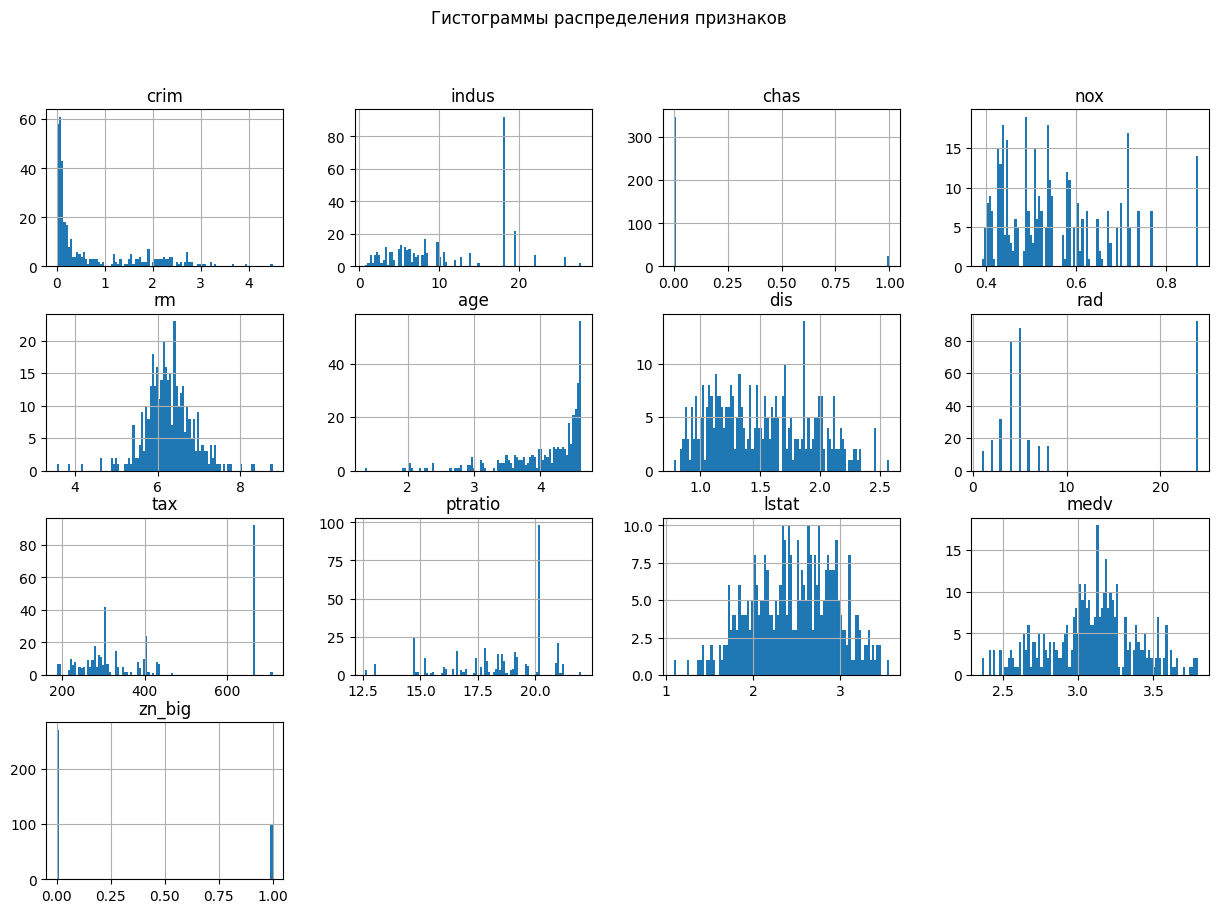

In [16]:
# Построение гистограмм для всех признаков
data_optimized.hist(figsize=(15, 10), bins=100)
plt.suptitle("Гистограммы распределения признаков")
plt.show()

In [17]:
df = data_optimized.copy()

y = df['medv']
X = df.drop('medv', axis=1)

preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), ['rad']),  # только rad
        ('minmax', MinMaxScaler(), data_optimized.columns.drop('medv').tolist())
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge()) 
])


In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline.fit(X_train, y_train)

pred_log = pipeline.predict(X_test)

mse = mean_squared_error(y_test, pred_log)
rmse = np.sqrt(mse)

print(f"Test MSE  = {mse:.6f}")
print(f"Test RMSE = {rmse:.6f}")

Test MSE  = 0.021206
Test RMSE = 0.145624


In [19]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lasso_pipeline = Pipeline([
    ('prep', preprocessor),
    ('lasso', Lasso(max_iter=20000, random_state=42))
])

param_grid = {
    'lasso__alpha': np.logspace(-5, -1, 50)
}

grid_search = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=param_grid,
    cv=5,                         
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

best_alpha = grid_search.best_params_['lasso__alpha']

best_model = grid_search.best_estimator_
pred_log = best_model.predict(X_val)

val_mse = mean_squared_error(y_val, pred_log)
val_rmse = np.sqrt(val_mse)

print(f"   Лучшее alpha       → {best_alpha:.6f}")
print(f"   MSE                → {val_mse:.6f}")
print(f"   RMSE               → {val_rmse:.6f}")

   Лучшее alpha       → 0.000168
   MSE                → 0.019038
   RMSE               → 0.137977


In [20]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=best_alpha),
    'Lasso': Lasso(alpha=best_alpha)
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    results[name] = -scores.mean() 

print("Результаты кросс-валидации (MSE):\n", results)

Результаты кросс-валидации (MSE):
 {'LinearRegression': np.float64(0.02180343090587034), 'Ridge': np.float64(0.021803377893274106), 'Lasso': np.float64(0.021807682498826107)}


In [21]:
data_test_optimized = data_test.copy()

data_test_optimized['crim']  = np.log1p(data_test_optimized['crim'])
data_test_optimized['dis']   = np.log1p(data_test_optimized['dis'])
data_test_optimized['lstat'] = np.log1p(data_test_optimized['lstat'])

data_test_optimized['age']   = np.log1p(data_test_optimized['age'])           
data_test_optimized['zn_big']    = (data_test_optimized['zn'] > 0).astype(int)
data_test_optimized.drop(['black'], axis=1, inplace=True)

data_test_optimized.drop(['zn'], axis=1, inplace=True)
data_categorical_features.append('zn_big')

data_test_optimized.head()

,crim,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,zn_big
0,0.075905,4.95,0.0,0.411,7.148,3.356897,1.811023,4.0,245.0,19.2,1.517323,1
1,0.085012,5.64,0.0,0.439,5.963,3.843744,2.056007,4.0,243.0,16.8,2.670694,1
2,0.870452,8.14,0.0,0.538,5.950,4.418841,1.607436,4.0,307.0,21.0,3.357245,0
3,0.265030,7.38,0.0,0.493,6.312,3.397858,1.858779,5.0,287.0,19.6,1.967112,0
4,0.206420,6.91,0.0,0.448,6.030,4.460144,1.900524,3.0,233.0,17.9,2.985682,0


In [22]:
df = data_optimized.copy()

y = df['medv']
X = df.drop('medv', axis=1)

preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), ['rad']), 
        ('minmax', MinMaxScaler(), data_optimized.columns.drop('medv').tolist())
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(best_alpha)) 
])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

pipeline.fit(X_train, y_train)
data_test_optimized['mdev_pred_log'] = pipeline.predict(data_test_optimized)
data_test_optimized['mdev_pred'] = np.expm1(pipeline.predict(data_test_optimized))


data_test_optimized.head()

,crim,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,zn_big,mdev_pred_log,mdev_pred
0,0.075905,4.95,0.0,0.411,7.148,3.356897,1.811023,4.0,245.0,19.2,1.517323,1,3.476495,31.346139
1,0.085012,5.64,0.0,0.439,5.963,3.843744,2.056007,4.0,243.0,16.8,2.670694,1,3.077580,20.705810
2,0.870452,8.14,0.0,0.538,5.950,4.418841,1.607436,4.0,307.0,21.0,3.357245,0,2.631059,12.888465
3,0.265030,7.38,0.0,0.493,6.312,3.397858,1.858779,5.0,287.0,19.6,1.967112,0,3.207435,23.715611
4,0.206420,6.91,0.0,0.448,6.030,4.460144,1.900524,3.0,233.0,17.9,2.985682,0,3.028579,19.667850
